<a href="https://colab.research.google.com/github/PURNACHANDRARAOPARCHURI/machine-larning/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
ar=np.array([[2,5,7,11,18,21,24,28,30],[8,10,13,16,19,21,27,32,21]])
ar=ar.T


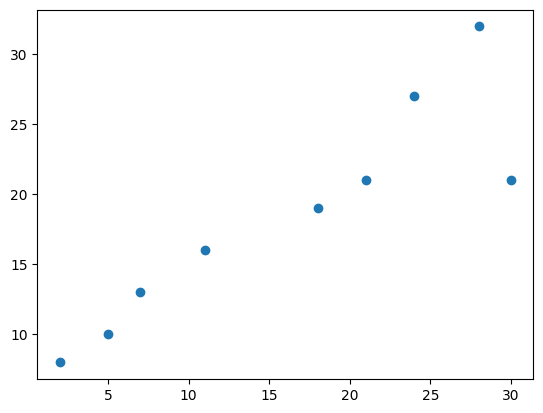

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(ar[:,0],ar[:,1])
plt.show()

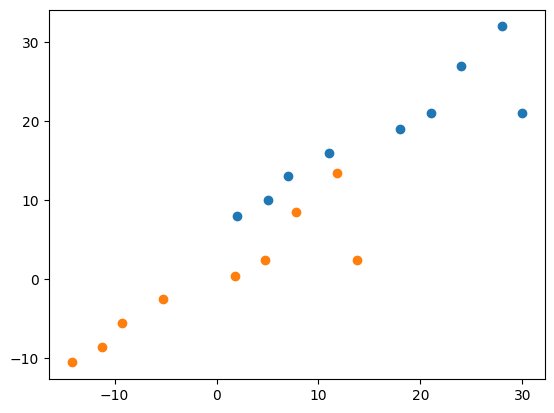

In [ ]:
ar1=ar-np.mean(ar,axis=0)
plt.figure()
plt.scatter(ar[:,0],ar[:,1])
plt.scatter(ar1[:,0],ar1[:,1])
plt.show()


In [ ]:
cov=np.cov(ar1,rowvar=False)


In [ ]:
eval,evec=np.linalg.eig(cov)
print(eval)
print(evec)
eval=eval[::-1]
evec=evec[:,::-1]
print(eval)
print(evec)

[160.05306433   7.6691579 ]
[[ 0.807144   -0.59035461]
 [ 0.59035461  0.807144  ]]
[  7.6691579  160.05306433]
[[-0.59035461  0.807144  ]
 [ 0.807144    0.59035461]]


In [ ]:
pca1_vector=evec[:,0]
pca1_vector=sorted.T
pca1_vector


array([-0.59035461,  0.807144  ])

In [ ]:
pca1=np.dot(ar1,pca1_vector)
pca1=pca1.T
pca1=pca1.sort()
pca1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


In [ ]:
data = {
    'Height': [170, 165, 180, 175, 160, 172, 168, 177, 162, 158],
    'Weight': [65, 59, 75, 68, 55, 70, 62, 74, 58, 54],
    'Age': [30, 25, 35, 28, 22, 32, 27, 33, 24, 21],
    'Gender': [1, 0, 1, 1, 0, 1, 0, 1, 0, 0]
}
df = pd.DataFrame(data)
print(df)

   Height  Weight  Age  Gender
0     170      65   30       1
1     165      59   25       0
2     180      75   35       1
3     175      68   28       1
4     160      55   22       0
5     172      70   32       1
6     168      62   27       0
7     177      74   33       1
8     162      58   24       0
9     158      54   21       0


In [ ]:
x=df.drop("Gender",axis=1)
y=df["Gender"]
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
pca=PCA(n_components=2)
pred=pca.fit_transform(x_scaled)
pred

array([[ 0.47934953,  0.24005867],
       [-1.04854122, -0.0462082 ],
       [ 2.73763841,  0.01704297],
       [ 0.87462551, -0.58608547],
       [-2.16068418, -0.02240454],
       [ 1.30013241,  0.33690873],
       [-0.30743041, -0.03219976],
       [ 2.15777883, -0.01054754],
       [-1.50115252,  0.08802759],
       [-2.53171635,  0.01540757]])

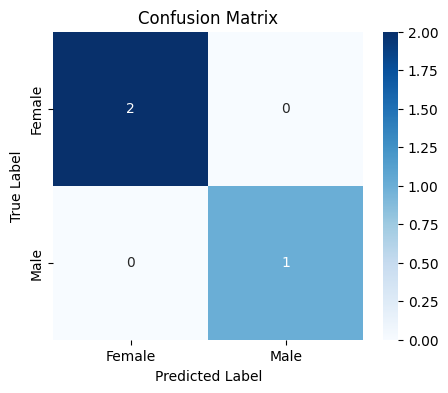

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(pred, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)
from sklearn.metrics import confusion_matrix
import seaborn as sns
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Female', 'Male'], yticklabels=['Female', 'Male'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()